In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import sys

# Ensure the script directory is in path if needed
if '.' not in sys.path:
    sys.path.append('.')

import updatedCroppingScript as cam

print("Constants from script:")
print(f"OFFSETS_MINUTES: {cam.OFFSETS_MINUTES}")
print(f"CHIP_HALF_SIZE:  {cam.CHIP_HALF_SIZE} (resulting in {2*cam.CHIP_HALF_SIZE}x{2*cam.CHIP_HALF_SIZE} chips)")

Constants from script:
OFFSETS_MINUTES: [-60, -40, -20, 0, 20, 40, 60]
CHIP_HALF_SIZE:  256 (resulting in 512x512 chips)


In [ ]:
# Example: Process Year 2020, Day 001, Orbit 72860
# Note: This requires ABIDATA, CLOUDSATPATH, etc. to be correctly set in the script.

# cam.processFile('2020', '001', '72860', (cam.latMin, cam.latMax))
print("Uncomment the line above to run processing directly.")

['/home/al8425b-hpc/NASA/cropTest/testData/cloudsat/2B-CLDCLASS-LIDAR/2020/001/2020001002545_72860_CS_2B-CLDCLASS-LIDAR_GRANULE_P1_R05_E09_F00.hdf']
['/home/al8425b-hpc/NASA/cropTest/testData/cloudsat/ECMWF-AUX/2020/001/2020001002545_72860_CS_ECMWF-AUX_GRANULE_P1_R05_E09_F00.hdf']
0.42929083930121525 2020 001 -0.005280808079987764 22.45724105834961 /home/al8425b-hpc/NASA/cropTest/testData/GOES_Data/ [-60, -40, -20, 0, 20, 40, 60] False Track Angle: 0.0
Latitude and Longitude are not correctly bounded
0.43017972813712224 2020 001 -0.19940561056137085 22.416040420532227 /home/al8425b-hpc/NASA/cropTest/testData/GOES_Data/ [-60, -40, -20, 0, 20, 40, 60] False Track Angle: 0.0
Latitude and Longitude are not correctly bounded
0.431068617105484 2020 001 -0.3935295641422272 22.374839782714844 /home/al8425b-hpc/NASA/cropTest/testData/GOES_Data/ [-60, -40, -20, 0, 20, 40, 60] False Track Angle: 0.0
Latitude and Longitude are not correctly bounded
0.43195750607384575 2020 001 -0.5876511335372925 

In [3]:
# Override if necessary
# cam.SAVEDIR = './data/abi-crop-test'

files = sorted(glob.glob(os.path.join(cam.SAVEDIR, "*.npz")))
print(f"Found {len(files)} processed files in {cam.SAVEDIR}")

if len(files) > 0:
    sample_path = files[0]
    print(f"Loading sample: {sample_path}")
    data_load = np.load(sample_path, allow_pickle=True)
    
    chip = data_load['chip']
    meta = data_load['data'].item()
    
    print(f"\nChip Shape (T, H, W, C): {chip.shape}")
    print(f"Meta keys: {list(meta.keys())}")
else:
    print("NO FILES FOUND. Please run the script first to generate outputs.")

Found 20 processed files in /home/al8425b-hpc/NASA/cropTest/testData/updatedOutput/
Loading sample: /home/al8425b-hpc/NASA/cropTest/testData/updatedOutput/2020-001-72861_9106-9247-4180.npz

Chip Shape (T, H, W, C): (7, 512, 512, 16)
Meta keys: ['Pressure', 'DEM_elevation', 'Temperature', 'Specific_humidity', 'Temperature_2m', 'U10_velocity', 'V10_velocity', 'UTC_Time', 'Latitude', 'Longitude', 'Cloud_mask', 'Cloud_mask_binary', 'Cloud_class', 'ABI_offsets_minutes', 'ABI_valid_mask', 'ABI_time_year', 'ABI_time_doy', 'ABI_time_utc_hour_decimal', 'ABI_time_hour', 'ABI_time_minute']


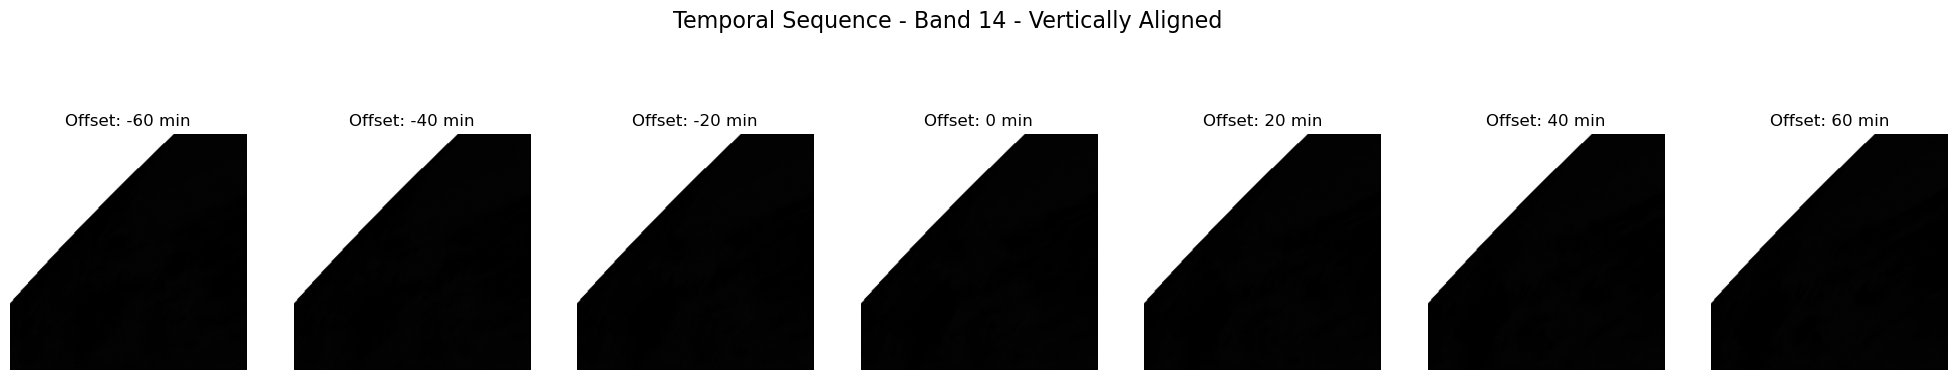

In [4]:
if len(files) > 0:
    band_to_plot = 13 # Band 14 (IR window)
    n_steps = chip.shape[0]
    
    fig, axes = plt.subplots(1, n_steps, figsize=(25, 5))
    
    for i in range(n_steps):
        # Use a colormap suitable for IR (e.g., 'gray' or 'inferno')
        axes[i].imshow(chip[i, :, :, band_to_plot], cmap='gray')
        offset = meta['ABI_offsets_minutes'][i]
        axes[i].set_title(f"Offset: {offset} min")
        axes[i].axis('off')
    
    plt.suptitle(f"Temporal Sequence - Band {band_to_plot+1} - Vertically Aligned", fontsize=16)
    plt.show()
else:
    print("Skip visualization: no data.")

Cloud Mask Shape: (91, 40)


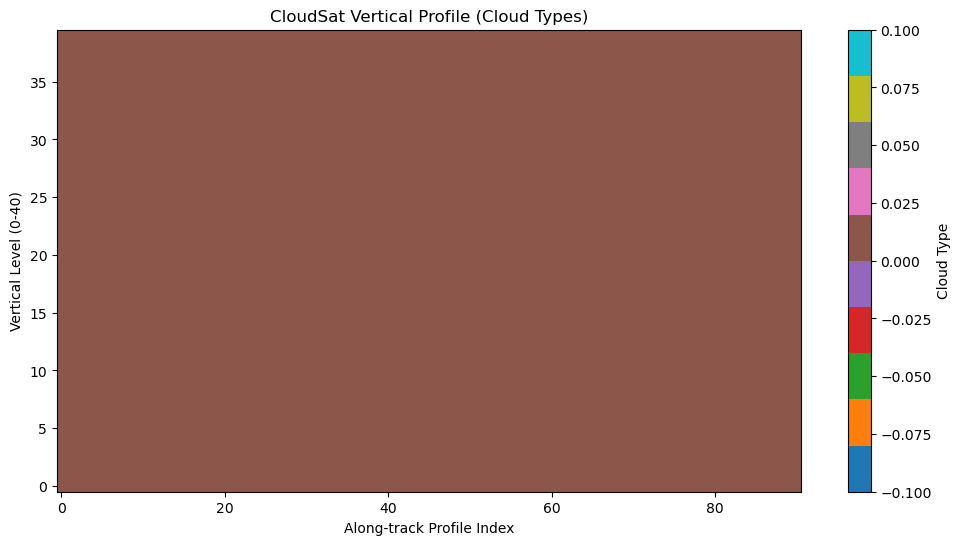

In [5]:
if len(files) > 0:
    mask = meta['Cloud_mask']
    print(f"Cloud Mask Shape: {mask.shape}") # (Profiles, Levels)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(mask.T, origin='lower', aspect='auto', cmap='tab10')
    plt.colorbar(label='Cloud Type')
    plt.title("CloudSat Vertical Profile (Cloud Types)")
    plt.xlabel("Along-track Profile Index")
    plt.ylabel("Vertical Level (0-40)")
    plt.show()
else:
    print("Skip visualization: no data.")